In [61]:
import os
import re
import glob
import random
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy

from sklearn.metrics import precision_recall_fscore_support, classification_report

In [62]:
# Semilla para que la selección aleatoria de oraciones sea reproducible.
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

# Carga del modelo preentrenado de spaCy.
nlp = spacy.load("en_core_web_sm")

print("Modelo cargado correctamente.")
print("Versión de spaCy:", spacy.__version__)

Modelo cargado correctamente.
Versión de spaCy: 3.8.14


In [63]:
# Buscar archivos de texto y tablas dentro del entorno de trabajo.

DATASET_DIR = Path(".")

archivos = sorted(
    [
        p for p in DATASET_DIR.rglob("*")
        if p.is_file() and p.suffix.lower() in [".txt", ".csv", ".json", ".xlsx"]
    ]
)

print("Archivos encontrados:")
for archivo in archivos:
    print("-", archivo)

Archivos encontrados:
- gutenberg_novels_dataset.csv


In [64]:

archivos_csv = [p for p in archivos if p.suffix.lower() == ".csv"]

for archivo in archivos_csv:
    print(f"\nArchivo: {archivo}")
    
    df_inspeccion = pd.read_csv(archivo)
    
    print("Dimensiones:", df_inspeccion.shape)
    print("Columnas:", list(df_inspeccion.columns))
    display(df_inspeccion.head())


Archivo: gutenberg_novels_dataset.csv
Dimensiones: (3, 6)
Columnas: ['gutenberg_id', 'title', 'author', 'download_url', 'text_length', 'text']


,gutenberg_id,title,author,download_url,text_length,text
0,1342,Pride and Prejudice,Jane Austen,https://www.gutenberg.org/files/1342/1342-0.txt,728392,*** START OF THE PROJECT GUTENBERG EBOOK 1342 ...
1,84,Frankenstein,Mary Shelley,https://www.gutenberg.org/files/84/84-0.txt,419290,*** START OF THE PROJECT GUTENBERG EBOOK 84 **...
2,345,Dracula,Bram Stoker,https://www.gutenberg.org/files/345/345-0.txt,845805,*** START OF THE PROJECT GUTENBERG EBOOK 345 *...


In [65]:
# Cargar el dataset completo desde el archivo CSV.

archivo_dataset = archivos_csv[0]
df = pd.read_csv(archivo_dataset)

print("Dataset cargado correctamente.")
print("Dimensiones:", df.shape)
print("Columnas:", list(df.columns))

# Mostrar la información principal de cada novela.
display(df[["gutenberg_id", "title", "author", "text_length"]])

Dataset cargado correctamente.
Dimensiones: (3, 6)
Columnas: ['gutenberg_id', 'title', 'author', 'download_url', 'text_length', 'text']


,gutenberg_id,title,author,text_length
0,1342,Pride and Prejudice,Jane Austen,728392
1,84,Frankenstein,Mary Shelley,419290
2,345,Dracula,Bram Stoker,845805


In [66]:
# Verificar que existan tres novelas y que cada una tenga texto.

if len(df) != 3:
    print(f"Advertencia: se encontraron {len(df)} registros en lugar de 3.")
else:
    print("Se encontraron exactamente tres novelas.")

for i, fila in df.iterrows():
    print(f"\nNovela {i + 1}")
    print("Título:", fila["title"])
    print("Autor:", fila["author"])
    print("Longitud registrada:", fila["text_length"])
    print("Longitud real del texto:", len(str(fila["text"])))
    print("Inicio del texto:")
    print(str(fila["text"])[:300])

Se encontraron exactamente tres novelas.

Novela 1
Título: Pride and Prejudice
Autor: Jane Austen
Longitud registrada: 728392
Longitud real del texto: 728392
Inicio del texto:
*** START OF THE PROJECT GUTENBERG EBOOK 1342 ***

                            [Illustration:

                             GEORGE ALLEN
                               PUBLISHER

                        156 CHARING CROSS ROAD
                                LONDON

                             RUSKI

Novela 2
Título: Frankenstein
Autor: Mary Shelley
Longitud registrada: 419290
Longitud real del texto: 419290
Inicio del texto:
*** START OF THE PROJECT GUTENBERG EBOOK 84 ***

Frankenstein;

or, the Modern Prometheus

by Mary Wollstonecraft (Godwin) Shelley

 CONTENTS

 Letter 1
 Letter 2
 Letter 3
 Letter 4
 Chapter 1
 Chapter 2
 Chapter 3
 Chapter 4
 Chapter 5
 Chapter 6
 Chapter 7
 Chapter 8
 Chapter 9
 Chapter 10
 Chapt

Novela 3
Título: Dracula
Autor: Bram Stoker
Longitud registrada: 845805
Longitud real del te

In [67]:
def limpiar_gutenberg(texto):
    """
    Elimina el encabezado y el final estándar de Project Gutenberg.
    """
    texto = str(texto).replace("\r\n", "\n").replace("\r", "\n")
    
    # Eliminar el encabezado de Project Gutenberg.
    patron_inicio = r"\*\*\* START OF (?:THE )?PROJECT GUTENBERG EBOOK.*?\*\*\*"
    texto = re.sub(patron_inicio, "", texto, count=1, flags=re.IGNORECASE | re.DOTALL)
    
    # Eliminar el cierre de Project Gutenberg.
    patron_final = r"\*\*\* END OF (?:THE )?PROJECT GUTENBERG EBOOK.*"
    texto = re.sub(patron_final, "", texto, count=1, flags=re.IGNORECASE | re.DOTALL)
    
    # Normalizar espacios y saltos de línea.
    texto = re.sub(r"[ \t]+", " ", texto)
    texto = re.sub(r"\n{3,}", "\n\n", texto)
    
    return texto.strip()

In [68]:
# Preparar el texto completo de cada novela.
# Se conservan las palabras y los signos de puntuación porque spaCy
# los utilizará como tokens durante el etiquetado POS y NER.

novelas = {}

for _, fila in df.iterrows():
    titulo = fila["title"]
    texto_limpio = limpiar_gutenberg(fila["text"])
    
    novelas[titulo] = {
        "titulo": titulo,
        "autor": fila["author"],
        "id": fila["gutenberg_id"],
        "texto": texto_limpio
    }

print("Novelas preparadas:")
for titulo, datos in novelas.items():
    print(f"- {titulo}: {len(datos['texto']):,} caracteres")

Novelas preparadas:
- Pride and Prejudice: 721,387 caracteres
- Frankenstein: 419,141 caracteres
- Dracula: 840,765 caracteres


In [69]:
# Segmentar cada novela en oraciones y tokens.
# Se utiliza spaCy únicamente para obtener las oraciones en esta etapa.
# El etiquetado POS y NER se aplicará posteriormente sobre las muestras.

nlp_preparacion = spacy.load("en_core_web_sm")
nlp_preparacion.max_length = 2_000_000

for titulo, datos in novelas.items():
    doc = nlp_preparacion(datos["texto"])
    
    oraciones = [
        sent.text.strip()
        for sent in doc.sents
        if len(sent.text.strip()) > 0
    ]
    
    tokens_totales = [
        token.text
        for token in doc
        if not token.is_space
    ]
    
    datos["oraciones"] = oraciones
    datos["tokens_totales"] = tokens_totales
    datos["num_oraciones"] = len(oraciones)
    datos["num_tokens"] = len(tokens_totales)
    
    print(
        f"{titulo}: "
        f"{datos['num_oraciones']:,} oraciones, "
        f"{datos['num_tokens']:,} tokens"
    )

Pride and Prejudice: 5,754 oraciones, 152,543 tokens
Frankenstein: 3,249 oraciones, 85,881 tokens
Dracula: 8,452 oraciones, 191,530 tokens


In [70]:
# Seleccionar una muestra aleatoria de 100 oraciones por novela.
# La misma muestra se utilizará como base para las secciones de POS.

for titulo, datos in novelas.items():
    cantidad_muestra = min(100, len(datos["oraciones"]))
    
    datos["muestra_oraciones"] = random.sample(
        datos["oraciones"],
        cantidad_muestra
    )
    
    datos["muestra_texto"] = " ".join(datos["muestra_oraciones"])
    
    datos["muestra_tokens"] = [
        token.text
        for token in nlp(datos["muestra_texto"])
        if not token.is_space
    ]
    
    datos["num_muestra_oraciones"] = len(datos["muestra_oraciones"])
    datos["num_muestra_tokens"] = len(datos["muestra_tokens"])

In [71]:
# Crear la tabla comparativa solicitada en la sección 1.

tabla_preparacion = pd.DataFrame([
    {
        "Novela": datos["titulo"],
        "Autor": datos["autor"],
        "Oraciones completas": datos["num_oraciones"],
        "Tokens completos": datos["num_tokens"],
        "Oraciones de muestra": datos["num_muestra_oraciones"],
        "Tokens de muestra": datos["num_muestra_tokens"]
    }
    for datos in novelas.values()
])

display(tabla_preparacion)

,Novela,Autor,Oraciones completas,Tokens completos,Oraciones de muestra,Tokens de muestra
0,Pride and Prejudice,Jane Austen,5754,152543,100,2675
1,Frankenstein,Mary Shelley,3249,85881,100,2641
2,Dracula,Bram Stoker,8452,191530,100,2299


In [72]:
# Aplicar el etiquetado POS a la muestra de cada novela.

docs_muestra = {}

for titulo, datos in novelas.items():
    doc = nlp(datos["muestra_texto"])
    docs_muestra[titulo] = doc
    
    print(
        f"{titulo}: "
        f"{sum(1 for token in doc if not token.is_space):,} tokens etiquetados"
    )

Pride and Prejudice: 2,675 tokens etiquetados
Frankenstein: 2,641 tokens etiquetados
Dracula: 2,299 tokens etiquetados


In [73]:
# Mostrar algunos tokens con sus etiquetas POS universal y Penn Treebank.

for titulo, doc in docs_muestra.items():
    print(f"\n--- {titulo} ---")
    
    ejemplos = [
        (token.text, token.pos_, token.tag_)
        for token in doc
        if not token.is_space
    ][:20]
    
    tabla_ejemplos = pd.DataFrame(
        ejemplos,
        columns=["Token", "POS universal", "Etiqueta Penn Treebank"]
    )
    
    display(tabla_ejemplos)


--- Pride and Prejudice ---


,Token,POS universal,Etiqueta Penn Treebank
0,“,PUNCT,``
1,You,PRON,PRP
2,have,VERB,VBP
3,no,DET,DT
4,regard,NOUN,NN
5,",",PUNCT,","
6,then,ADV,RB
7,",",PUNCT,","
8,for,ADP,IN
9,the,DET,DT



--- Frankenstein ---


,Token,POS universal,Etiqueta Penn Treebank
0,I,PRON,PRP
1,gazed,VERB,VBD
2,on,ADP,IN
3,the,DET,DT
4,picture,NOUN,NN
5,of,ADP,IN
6,my,PRON,PRP$
7,mother,NOUN,NN
8,",",PUNCT,","
9,which,PRON,WDT



--- Dracula ---


,Token,POS universal,Etiqueta Penn Treebank
0,Indeed,ADV,RB
1,",",PUNCT,","
2,I,PRON,PRP
3,am,AUX,VBP
4,writing,VERB,VBG
5,now,ADV,RB
6,",",PUNCT,","
7,with,ADP,IN
8,my,PRON,PRP$
9,book,NOUN,NN


In [74]:
# Calcular la distribución de categorías gramaticales de cada novela.
# Se excluyen los espacios porque no son tokens lingüísticos.

distribuciones_pos = []

for titulo, doc in docs_muestra.items():
    contador_pos = Counter(
        token.pos_
        for token in doc
        if not token.is_space
    )
    
    total_tokens = sum(contador_pos.values())
    
    for categoria, frecuencia in contador_pos.items():
        distribuciones_pos.append({
            "Novela": titulo,
            "POS": categoria,
            "Frecuencia": frecuencia,
            "Porcentaje": 100 * frecuencia / total_tokens
        })

tabla_pos = pd.DataFrame(distribuciones_pos)

# Tabla de frecuencias absolutas.
tabla_pos_pivot = tabla_pos.pivot(
    index="POS",
    columns="Novela",
    values="Frecuencia"
).fillna(0).astype(int)

display(tabla_pos_pivot)

Novela,Dracula,Frankenstein,Pride and Prejudice
POS,,,
ADJ,111,156,141
ADP,207,283,270
ADV,130,109,150
AUX,155,130,190
CCONJ,82,122,92
DET,177,221,170
INTJ,2,3,3
NOUN,298,430,343
NUM,8,7,22


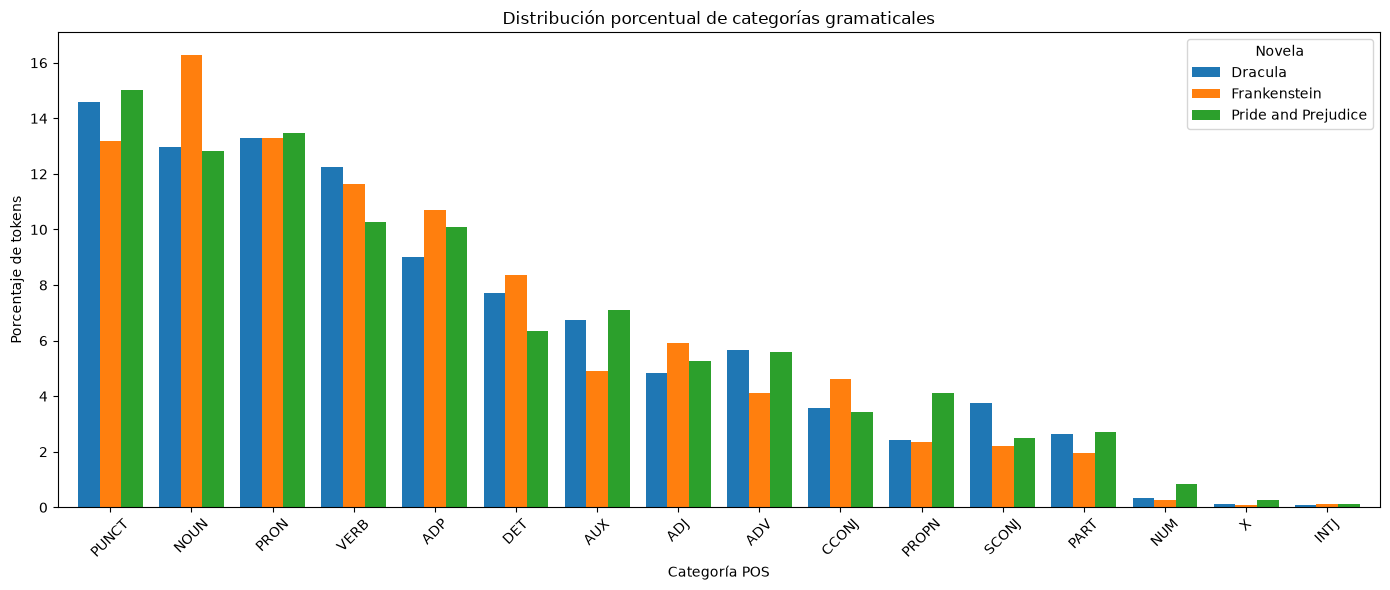

In [75]:
# Gráfico de barras agrupadas para comparar las categorías POS.
# Se utilizan porcentajes para que las novelas sean comparables
# aunque sus muestras tengan diferente número de tokens.

tabla_pos_porcentajes = tabla_pos.pivot(
    index="POS",
    columns="Novela",
    values="Porcentaje"
).fillna(0)

orden_pos = tabla_pos_porcentajes.mean(axis=1).sort_values(
    ascending=False
).index

tabla_pos_porcentajes = tabla_pos_porcentajes.loc[orden_pos]

ax = tabla_pos_porcentajes.plot(
    kind="bar",
    figsize=(14, 6),
    width=0.8
)

ax.set_title("Distribución porcentual de categorías gramaticales")
ax.set_xlabel("Categoría POS")
ax.set_ylabel("Porcentaje de tokens")
plt.xticks(rotation=45)
plt.legend(title="Novela")
plt.tight_layout()
plt.show()

In [76]:
# Buscar palabras que reciben más de una etiqueta POS
# en diferentes contextos de las muestras.

usos_palabras = defaultdict(list)

for titulo, doc in docs_muestra.items():
    for token in doc:
        if (
            not token.is_space
            and token.is_alpha
            and len(token.text) > 2
        ):
            palabra = token.text.lower()
            
            inicio = max(0, token.i - 5)
            fin = min(len(doc), token.i + 6)
            
            contexto = " ".join(
                t.text for t in doc[inicio:fin]
                if not t.is_space
            )
            
            usos_palabras[palabra].append({
                "Novela": titulo,
                "Palabra": token.text,
                "POS": token.pos_,
                "Etiqueta": token.tag_,
                "Contexto": contexto
            })

# Conservar palabras que aparecen con al menos dos categorías POS.
palabras_ambiguas = []

for palabra, usos in usos_palabras.items():
    etiquetas = set(uso["POS"] for uso in usos)
    
    if len(etiquetas) >= 2:
        palabras_ambiguas.append({
            "Palabra": palabra,
            "Número de POS": len(etiquetas),
            "POS encontradas": ", ".join(sorted(etiquetas)),
            "Frecuencia": len(usos)
        })

tabla_ambiguas = pd.DataFrame(palabras_ambiguas)

tabla_ambiguas = tabla_ambiguas.sort_values(
    by=["Número de POS", "Frecuencia"],
    ascending=False
)

display(tabla_ambiguas.head(15))

,Palabra,Número de POS,POS encontradas,Frecuencia
3,that,3,"DET, PRON, SCONJ",88
9,but,3,"ADV, CCONJ, SCONJ",43
16,all,3,"ADV, DET, PRON",39
43,before,3,"ADP, ADV, SCONJ",13
26,after,3,"ADP, ADV, SCONJ",11
34,good,3,"ADJ, NOUN, PROPN",11
47,like,3,"ADJ, ADP, VERB",10
64,right,3,"ADJ, ADV, NOUN",5
51,either,3,"CCONJ, DET, PRON",3
2,the,2,"DET, PRON",308


In [77]:
# Seleccionar tres palabras ambiguas y mostrar dos contextos
# donde reciban etiquetas POS diferentes.

palabras_seleccionadas = []

for _, fila in tabla_ambiguas.iterrows():
    palabra = fila["Palabra"]
    usos = usos_palabras[palabra]
    
    etiquetas_distintas = {}
    
    for uso in usos:
        etiquetas_distintas.setdefault(uso["POS"], uso)
    
    if len(etiquetas_distintas) >= 2:
        palabras_seleccionadas.append(palabra)
    
    if len(palabras_seleccionadas) == 3:
        break

ejemplos_ambiguedad = []

for palabra in palabras_seleccionadas:
    usos = usos_palabras[palabra]
    etiquetas_distintas = {}
    
    for uso in usos:
        etiquetas_distintas.setdefault(uso["POS"], uso)
    
    for uso in list(etiquetas_distintas.values())[:3]:
        ejemplos_ambiguedad.append(uso)

tabla_ambiguedad = pd.DataFrame(ejemplos_ambiguedad)

display(
    tabla_ambiguedad[
        ["Palabra", "Novela", "POS", "Etiqueta", "Contexto"]
    ]
)

,Palabra,Novela,POS,Etiqueta,Contexto
0,that,Pride and Prejudice,SCONJ,IN,"! He really believed that , were it not for"
1,that,Pride and Prejudice,DET,DT,should be forced to have that disagreeable man...
2,That,Pride and Prejudice,PRON,DT,", said aloud,-- “ That will do extremely well ,"
3,but,Pride and Prejudice,CCONJ,CC,"to believe almost anything , but no one else c..."
4,but,Frankenstein,SCONJ,IN,saw around me nothing but a dense and frightfu...
5,but,Dracula,ADV,CC,howling of the wolves was but short . The rays
6,all,Pride and Prejudice,DET,DT,"to be deceived , by all means . “ Ah ,"
7,all,Pride and Prejudice,PRON,DT,have that disagreeable man all to yourself ; b...
8,all,Pride and Prejudice,ADV,RB,"proud . “ You are all kindness , madam ; but"
